# Physics 234: Computational Physics

# Lecture 1:  Numerical Results Based on Analytical Solutions

The course will focus on the "Physics" part of computational physics.  We will end up doing a significant amount of computing, and write a number of programs, but we will be directed by considering particular physics examples.  We will get into the details of computing- but not the "heavy duty" algorithm development- as we go along.

We will be using canvas quizzes/polls based on wooclap (and your participation/answers will form part of your final grade) to get feedback.  Let's start with a question of familiarity with programming.

And a question of numerical solution to physics problems...

It used to be that closed form, anaytical solutions enabled the extraction of numerical quantitites.  That is not the case any longer.  Are analytical solutions still useful?

\begin{equation}
\int \frac{1}{ax^2+bx+c}dx = \frac{2}{\sqrt{4ac-b^2}}\tan^{-1}\frac{2ax+b}{\sqrt{4ac-b^2}}
\end{equation}





Integral between 1 and 2 for a=3, b=4, c=5 is  0.05809380401645287


Text(0.5, 1.0, 'Plot of the integral $\\int_1^{x_2}\\frac{dx}{3x^2+4x+5}$')

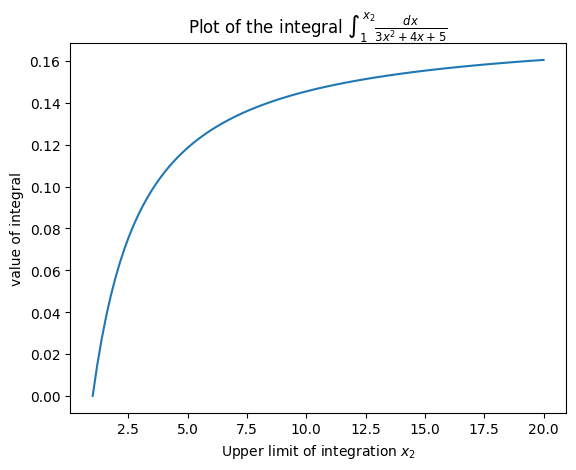

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
def integral(x1,x2,a,b,c): # calculate integral of 1/(ax**2+bx+c) between x1 and x2
    return quad(lambda x:1/(a*x**2+b*x+c),x1,x2)[0]
    
print('Integral between 1 and 2 for a=3, b=4, c=5 is ', integral(1,2,3,4,5))

xlist=np.linspace(1,20,100)
plt.plot(xlist, [integral(1,x2,3,4,5) for x2 in xlist])
plt.xlabel('Upper limit of integration $x_2$')
plt.ylabel('value of integral')
plt.title(r'Plot of the integral $\int_1^{x_2}\frac{dx}{3x^2+4x+5}$')

In this course we will learn how to do computer calculations to solve physics problems.  We start by using the computer as a calculator, and then set up general numerical techniques to differentiate, integrate, solve equations, interpolate functions.  

## Problem:  Constant acceleration
A ball is thrown at a velocity of 140 km/h, and in a direction 30 degrees east of north, from a height of 2 meters, leaving at an angle 40 degrees from the horizontal.  When and where does the ball hit the ground?  Divide the time interval into 100 steps.  At each step print out the components of position, velocity and acceleration.  

Then plot the x,y,z components of the position, velocity and acceleration as a function of time.  


We use this problem to introduce the numerics of simple calculations and variables in Python, as well as output, libraries, and plotting.






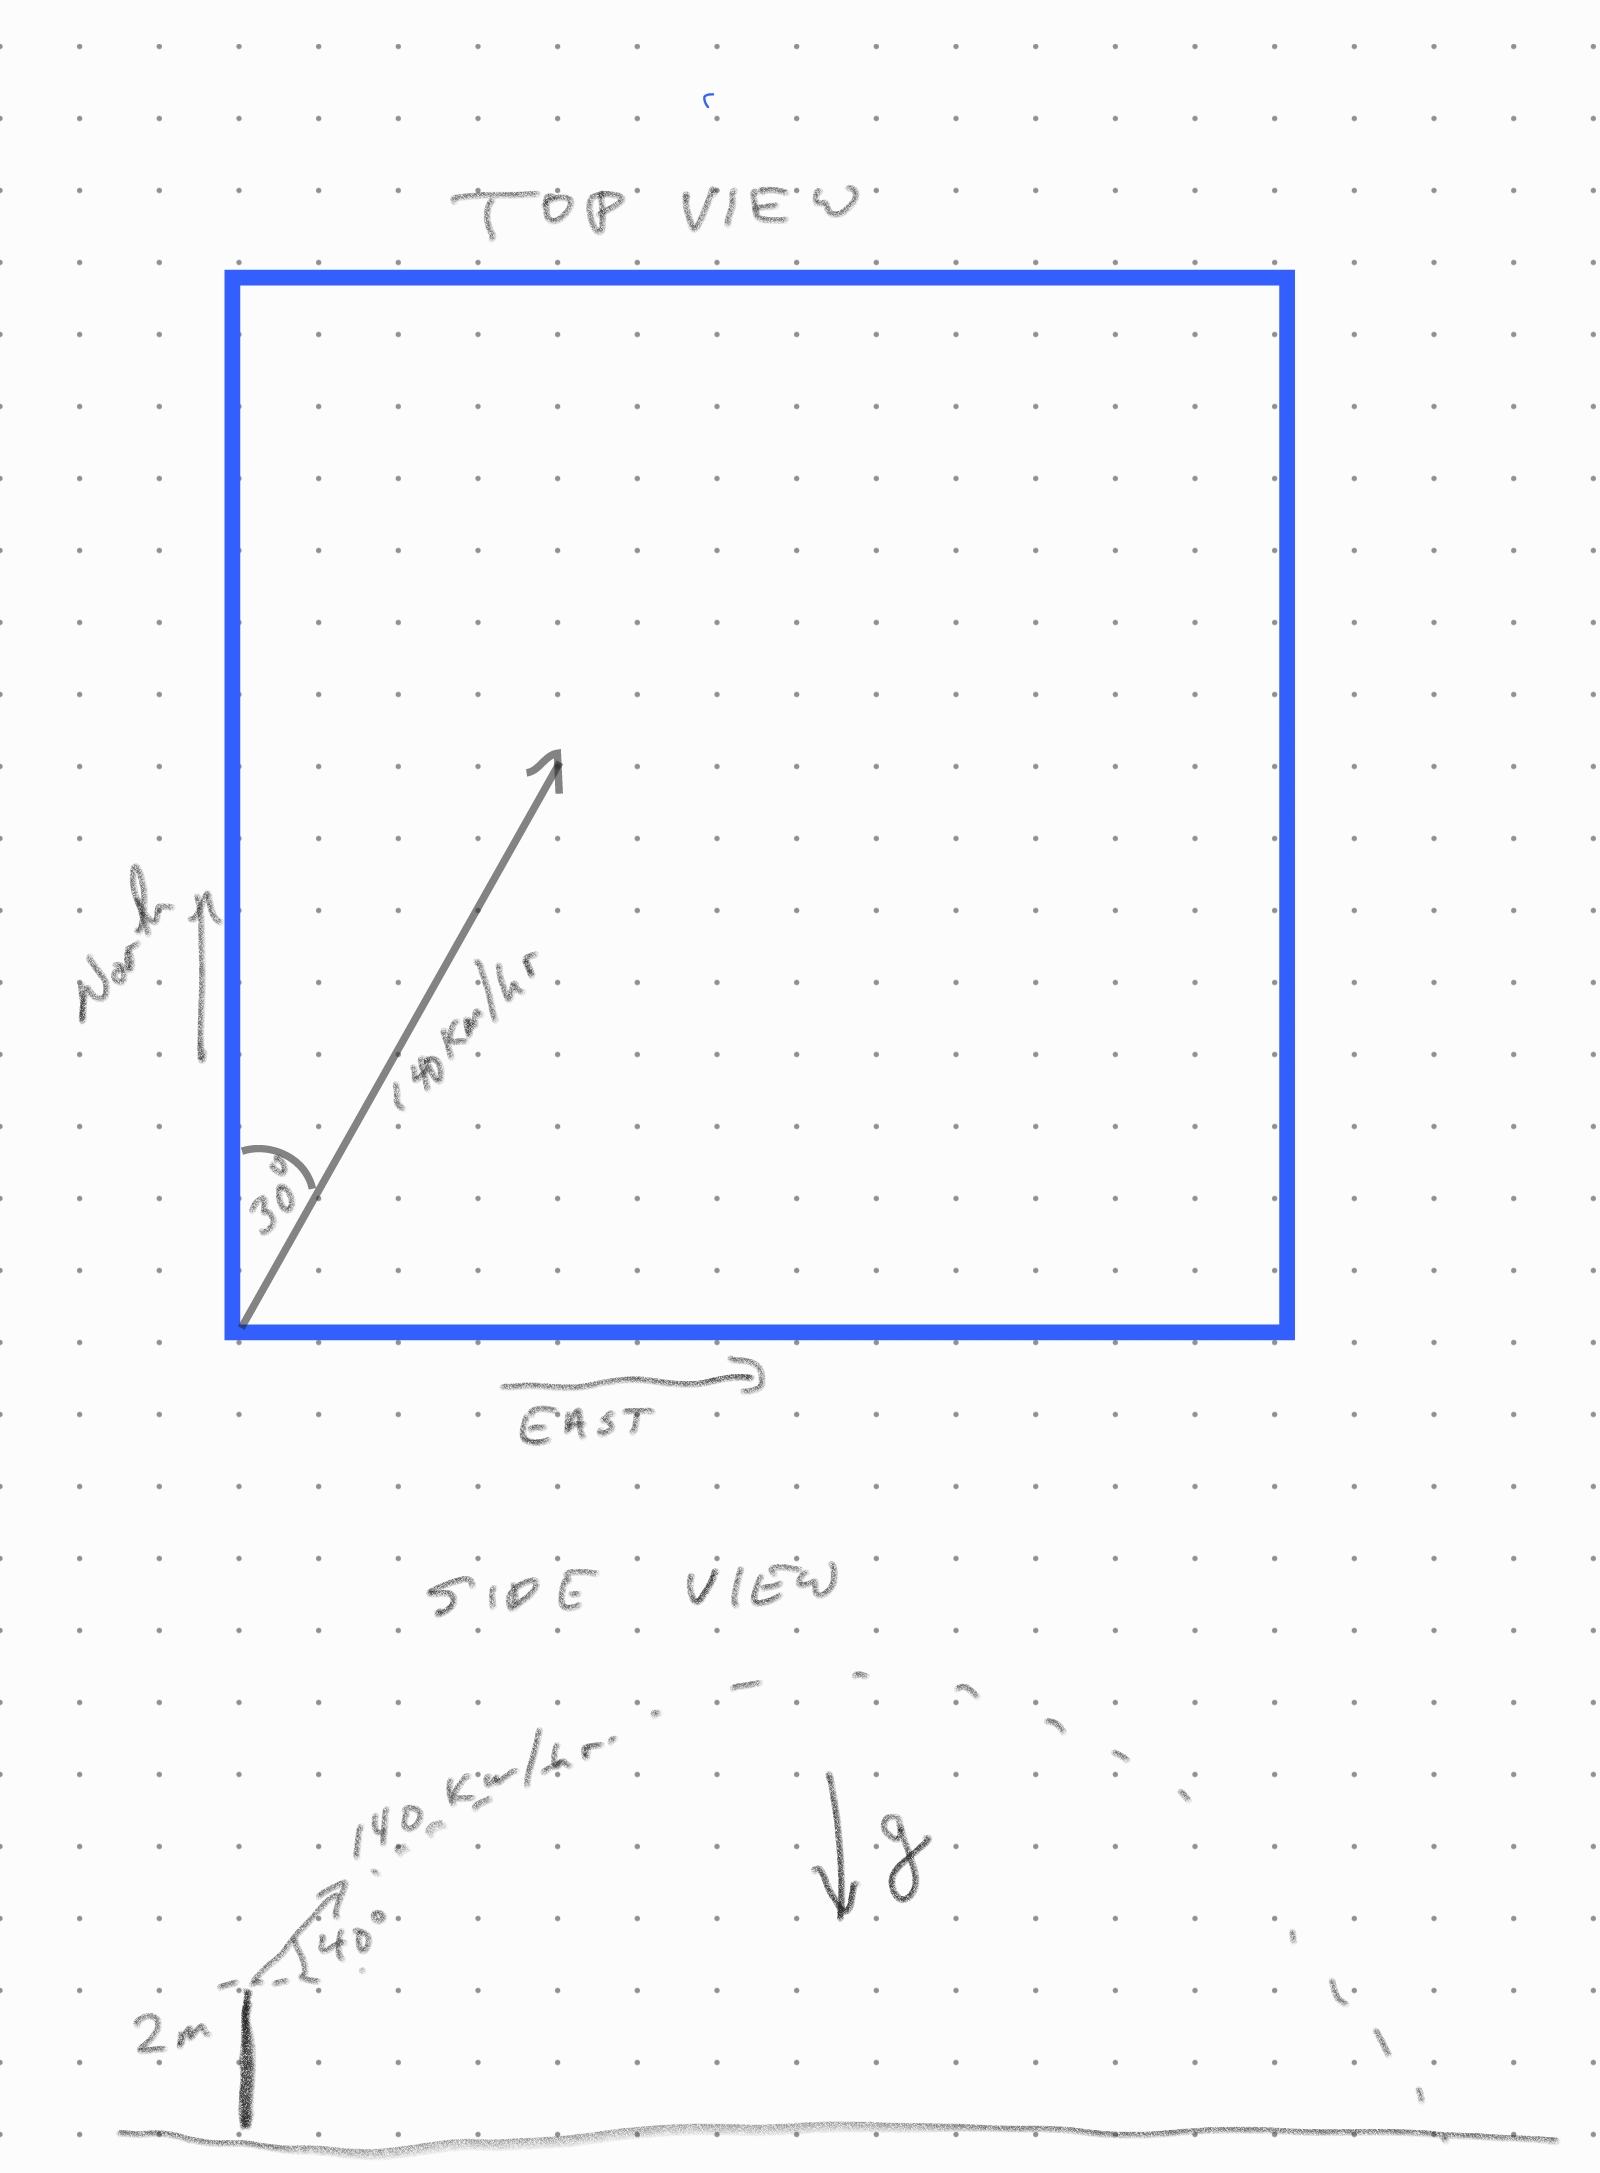




## Free body diagram

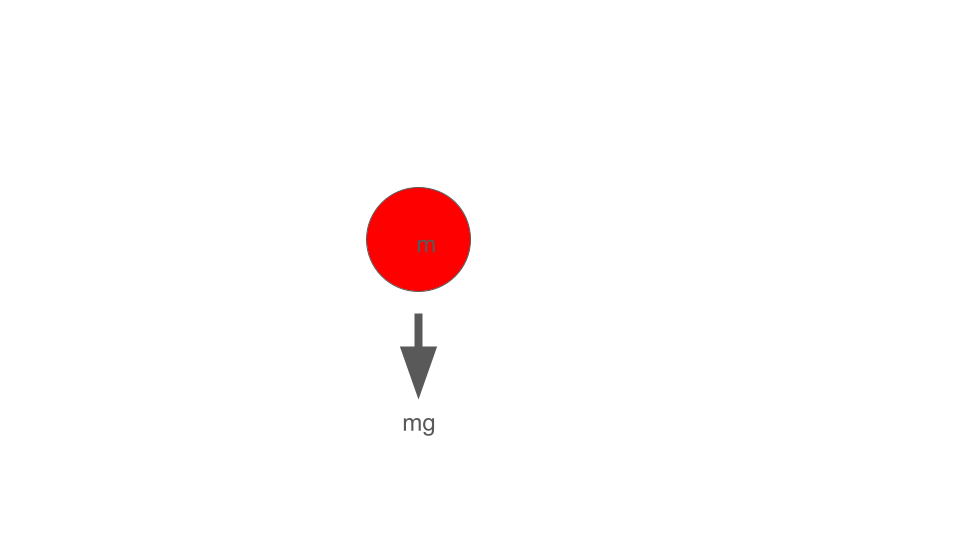



$$\vec{F}=m\vec{g}$$

Once we know the force, we set up the simple differential equations that allow us to use the acceleration to calculate the velocity and the velocity to calculate the positon as a function of time.  

$$\vec{F}=m\vec{a} $$

$$\vec{a}=\vec{g} \rightarrow \frac{d\vec{v}}{dt}=\vec{g} \rightarrow \vec{v}=\vec{v_0}+\vec{g}t $$

$$\vec{v}=\vec{v_0}+\vec{g}t \rightarrow \vec{x}=\vec{x_0} +\vec{v_0}t+\frac{1}{2} \vec{g}t^2 $$ 

With this set of equations, that everyone has seen before, we can solve for the time when the ball strikes the ground, using a quadratic equation.

The vector equations are actually three equations-- one for the x, one for the y, and one for the z-component.  

The solution to the z-component gives us the time:

$$ 0=x_{0,z}+v_{0,z}t+\frac{1}{2}gt^2.$$

with $x_{0,z}=2\rm{m}$, $v_{0,z}=140 \sin(40^o) \rm{km/h}$, $g=-9.8 \rm{m/s^2}.$

The solution to the quadratic equation $ax^2+bx+c$ is $x=\frac{-b\pm \sqrt{b^2-4ac}}{2a},$ so we end up with $t=\frac{-v_{0,z} \pm \sqrt{v_{0,z}^2-2x_{0,z}g}} {g}.$ 

We write our first little python code to do this calculation.

In [2]:
import math  #need a library for sin, cos pi
x_0z=2 #m
v_0z=140 * 1000./3600*math.sin(40.0/180*math.pi) # 140 km/hr converted to m/s
g= -9.8 # m/s/s

print (x_0z, v_0z, g)
g

2 24.997295932254303 -9.8


-9.8

In [3]:
help(x_0z)

Help on int object:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |  
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating point
 |  numbers, this truncates towards zero.
 |  
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |  
 |  Built-in subclasses:
 |      bool
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __and__(self, value, /)
 |      Return self&value.
 |  
 |  __bool__(self, /)
 |      True if self else False
 |

In [4]:
help(v_0z)

Help on float object:

class float(object)
 |  float(x=0, /)
 |  
 |  Convert a string or number to a floating point number, if possible.
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __bool__(self, /)
 |      True if self else False
 |  
 |  __ceil__(self, /)
 |      Return the ceiling as an Integral.
 |  
 |  __divmod__(self, value, /)
 |      Return divmod(self, value).
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __float__(self, /)
 |      float(self)
 |  
 |  __floor__(self, /)
 |      Return the floor as an Integral.
 |  
 |  __floordiv__(self, value, /)
 |      Return self//value.
 |  
 |  __format__(self, format_spec, /)
 |      Formats the float according to format_spec.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __getnewargs__(self, /)
 |  
 |  __gt__(sel

In [5]:
help(math)

Help on module math:

NAME
    math

MODULE REFERENCE
    https://docs.python.org/3.9/library/math
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    This module provides access to the mathematical functions
    defined by the C standard.

FUNCTIONS
    acos(x, /)
        Return the arc cosine (measured in radians) of x.
        
        The result is between 0 and pi.
    
    acosh(x, /)
        Return the inverse hyperbolic cosine of x.
    
    asin(x, /)
        Return the arc sine (measured in radians) of x.
        
        The result is between -pi/2 and pi/2.
    
    asinh(x, /)
        Return the inverse hyperbolic sine of x.
    
    atan(x, /)
        Return the arc tangent (measured in 

In [6]:
help(print)

Help on built-in function print in module builtins:

print(...)
    print(value, ..., sep=' ', end='\n', file=sys.stdout, flush=False)
    
    Prints the values to a stream, or to sys.stdout by default.
    Optional keyword arguments:
    file:  a file-like object (stream); defaults to the current sys.stdout.
    sep:   string inserted between values, default a space.
    end:   string appended after the last value, default a newline.
    flush: whether to forcibly flush the stream.



Python is nice that it has "help" for almost everything.  But sometimes the help is terse/confusing.  However, there is an incredible amount of information out there about python-- so just google terms or issues that you have problems with.   

There is also the "help pages" in the Jupyter Notebook itself.

In [7]:
# for output, we can use an "f-string", or also a "formatted string literal"
out=f'The ball is thrown from a height {x_0z} m at vertical velocity {v_0z} m/s and g={g} m/s/s.'
print(out)

The ball is thrown from a height 2 m at vertical velocity 24.997295932254303 m/s and g=-9.8 m/s/s.


In [8]:
#make things a little neater, and some attention to significant figures.  
# How many significant figures should we use? 
out=f'The ball is thrown from a height {x_0z} m at vertical velocity {v_0z:5.2f} m/s and g={g} m/s/s.'
print(out)
print(f'The ball is thrown from a height {x_0z} m at vertical velocity {v_0z:5.2f} m/s and g={g} m/s/s.')

The ball is thrown from a height 2 m at vertical velocity 25.00 m/s and g=-9.8 m/s/s.
The ball is thrown from a height 2 m at vertical velocity 25.00 m/s and g=-9.8 m/s/s.


In [9]:
q=math.sqrt(v_0z**2-2*g*x_0z)
print(f'q={q:5.2f}')
solution1=(-v_0z+q)/g

solution2=(-v_0z-q)/g
print(f'The solutions are {solution1} and {solution2} s.' )
#now with the maximum number of significant figures
print(f'The solutions are {solution1:5.2f} and {solution2:5.2f} s.' )


q=25.77
The solutions are -0.07879172760434952 and 5.180280693370533 s.
The solutions are -0.08 and  5.18 s.


# Validation!!!

When solving problems "by hand" you probably had the good habit of checking whether your solution was right by substituting back into the equation to see if it worked-- that is much easier than solving and then you are certain you are right.  It is even more critical when you write a program.  Programs almost never do what you want them to do!  A necessary habit- and one we will do for every program we write this year will be to think of how to validate them-- it could be that the validation is almost half the work in writing a program.  But never trust a result unless you have tested it.

We will test our results by just plugging them into our equation.  

What about significant figures here?  

In [10]:
t=solution1
test1=x_0z+v_0z*t+0.5*g*t**2
t=solution2
test2=x_0z+v_0z*t+0.5*g*t**2

print(f'We validate and find the height of the ball when it strikes the ground to be {test1} and {test2} m')

We validate and find the height of the ball when it strikes the ground to be 2.2898349882893854e-15 and 0.0 m


## Functions

We wrote the same code twice.  That is probably not the end of the world, but if we are using the same operation, particularly if it is more than a line or two multiple times, it pays to write a function.  That enables us to do the code over and over again.

In [11]:
def h(t, xz,vz,az):
    'calculate the height of a projectile undergoing constant acceleration'
    return xz+vz*t+0.5*az*t**2

def roots(xz,vz,az):
    'Find the times when a projectile hits the ground'
    q=math.sqrt(vz**2-2*xz*az)
    return [(-vz+q)/az,(-vz-q)/az]


In [12]:
help(h)

Help on function h in module __main__:

h(t, xz, vz, az)
    calculate the height of a projectile undergoing constant acceleration



In [13]:
r=roots(x_0z,v_0z,g)  #notice here we have returned a list
help(r)

Help on list object:

class list(object)
 |  list(iterable=(), /)
 |  
 |  Built-in mutable sequence.
 |  
 |  If no argument is given, the constructor creates a new empty list.
 |  The argument must be an iterable if specified.
 |  
 |  Methods defined here:
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __contains__(self, key, /)
 |      Return key in self.
 |  
 |  __delitem__(self, key, /)
 |      Delete self[key].
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __getitem__(...)
 |      x.__getitem__(y) <==> x[y]
 |  
 |  __gt__(self, value, /)
 |      Return self>value.
 |  
 |  __iadd__(self, value, /)
 |      Implement self+=value.
 |  
 |  __imul__(self, value, /)
 |      Implement self*=value.
 |  
 |  __init__(self, /, *args, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate sign

In [14]:
help([])

Help on list object:

class list(object)
 |  list(iterable=(), /)
 |  
 |  Built-in mutable sequence.
 |  
 |  If no argument is given, the constructor creates a new empty list.
 |  The argument must be an iterable if specified.
 |  
 |  Methods defined here:
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __contains__(self, key, /)
 |      Return key in self.
 |  
 |  __delitem__(self, key, /)
 |      Delete self[key].
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __getitem__(...)
 |      x.__getitem__(y) <==> x[y]
 |  
 |  __gt__(self, value, /)
 |      Return self>value.
 |  
 |  __iadd__(self, value, /)
 |      Implement self+=value.
 |  
 |  __imul__(self, value, /)
 |      Implement self*=value.
 |  
 |  __init__(self, /, *args, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate sign

In [15]:
print(r)

[-0.07879172760434952, 5.180280693370533]


In [16]:
#list comprehension.  A fancy name for a simple idea
tests=[h(t,x_0z,v_0z,g) for t in r]  # we can make a list by doing something for each element in another list  
print(tests)

[2.2898349882893854e-15, 0.0]


A function name can be used as a variable. To copy a function, just use the "=" sign:

In [17]:
testfunction=h
testfunction(r[1],x_0z,v_0z,g)

0.0

## Is this the right way to do the code?  

Actually, probably not.  Although given that the functions are only two lines long, it isn't terrible.  

The enormous advantage of Python is that there are incredible libraries out there-- so lets look at the help function, and in particularly at "numpy" (there in the Jupyter help) and at scipy(also in the Jupyter help).  

In particular, there is a library class named numpy.polynomial.Polynomial, which we can use, along with its roots, method, that will solve the quadratic equation.  

Let's do the problem that way.


In [18]:
from numpy.polynomial import Polynomial as P

In [19]:
help(P)

Help on class Polynomial in module numpy.polynomial.polynomial:

class Polynomial(numpy.polynomial._polybase.ABCPolyBase)
 |  Polynomial(coef, domain=None, window=None, symbol='x')
 |  
 |  A power series class.
 |  
 |  The Polynomial class provides the standard Python numerical methods
 |  '+', '-', '*', '//', '%', 'divmod', '**', and '()' as well as the
 |  attributes and methods listed below.
 |  
 |  Parameters
 |  ----------
 |  coef : array_like
 |      Polynomial coefficients in order of increasing degree, i.e.,
 |      ``(1, 2, 3)`` give ``1 + 2*x + 3*x**2``.
 |  domain : (2,) array_like, optional
 |      Domain to use. The interval ``[domain[0], domain[1]]`` is mapped
 |      to the interval ``[window[0], window[1]]`` by shifting and scaling.
 |      The default value is [-1, 1].
 |  window : (2,) array_like, optional
 |      Window, see `domain` for its use. The default value is [-1, 1].
 |  
 |      .. versionadded:: 1.6.0
 |  symbol : str, optional
 |      Symbol used to r

In [20]:
eq=P([x_0z, v_0z,0.5*g])# create the polynomial from a list of the terms
solutions=eq.roots() #use the polynomial solutions library routine
tests=[eq(x) for x in solutions]
print('The solutions are ', solutions, 's.')
print('Validate.  The height of the ball at the solutions are', tests, 'm.')

The solutions are  [-0.07879173  5.18028069] s.
Validate.  The height of the ball at the solutions are [np.float64(0.0), np.float64(-7.105427357601002e-15)] m.


# Numerical precision
What about those 1e-15?  That should be zero, for a mathematical solution.  Here is the first place we run into the fact that real numbers in a computer don't have arbitrary precision, but are represented only approximately.  We will come back to this a little bit more when we start to talk about numerical derivatives.  The issue is that we end up with the 1e-15 by adding three numbers together-- all with magnitudes >1, and find that they cancel out to a part in 1e15.  So, for now we will assume 1e-15 is zero (physically 1e-15 m is the size of a nucleus, so it really doesn't matter too much for any practical purposes!)

# Reminder of the Problem: Constant acceleration
A ball is thrown at a velocity of 140 km/h, and in a direction 30 degrees east of north, from a height of 2 meters, leaving at an angle 40 degrees from the horizontal. When and where does the ball hit the ground? Divide the time interval into 100 steps. At each step print out the components of position, velocity and acceleration.

Then plot the x,y,z components of the position, velocity and acceleration as a function of time.

We use this problem to introduce the numerics of simple calculations and variables in Python, as well as output, libraries, and plotting.

Now we know the time interval (from zero to solutions[1]).  The next step is to divide the time interval into 100 steps, and calculate the position

# Vectors

Position, velocity and acceleration are all vectors.  There is a big temptation among students to do things with coordinates and break the vector equations into single coordinate equations.  Don't!  It is more work and it leads to less readable and error-prone code.  

Instead, we will use numpy.array, which represent a list of numbers.   (which is more general than the mathematical vector, but which allows for vector operations, in addition to "spread-sheet" like operations). We look at both np.array, np.dot and np.cross (which do dot and cross products) and np.linalg for specific vector like operations. 

In [21]:
import numpy as np
help(np.array)

Help on built-in function array in module numpy:

array(...)
    array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
          like=None)
    
    Create an array.
    
    Parameters
    ----------
    object : array_like
        An array, any object exposing the array interface, an object whose
        ``__array__`` method returns an array, or any (nested) sequence.
        If object is a scalar, a 0-dimensional array containing object is
        returned.
    dtype : data-type, optional
        The desired data-type for the array. If not given, NumPy will try to use
        a default ``dtype`` that can represent the values (by applying promotion
        rules when necessary.)
    copy : bool, optional
        If ``True`` (default), then the array data is copied. If ``None``,
        a copy will only be made if ``__array__`` returns a copy, if obj is
        a nested sequence, or if a copy is needed to satisfy any of the other
        requirements (``dtype``, ``o

In [22]:
help(np.dot)

Help on _ArrayFunctionDispatcher in module numpy:

dot(...)
    dot(a, b, out=None)
    
    Dot product of two arrays. Specifically,
    
    - If both `a` and `b` are 1-D arrays, it is inner product of vectors
      (without complex conjugation).
    
    - If both `a` and `b` are 2-D arrays, it is matrix multiplication,
      but using :func:`matmul` or ``a @ b`` is preferred.
    
    - If either `a` or `b` is 0-D (scalar), it is equivalent to
      :func:`multiply` and using ``numpy.multiply(a, b)`` or ``a * b`` is
      preferred.
    
    - If `a` is an N-D array and `b` is a 1-D array, it is a sum product over
      the last axis of `a` and `b`.
    
    - If `a` is an N-D array and `b` is an M-D array (where ``M>=2``), it is a
      sum product over the last axis of `a` and the second-to-last axis of
      `b`::
    
        dot(a, b)[i,j,k,m] = sum(a[i,j,:] * b[k,:,m])
    
    It uses an optimized BLAS library when possible (see `numpy.linalg`).
    
    Parameters
    -----

In [23]:
help (np.cross)

Help on _ArrayFunctionDispatcher in module numpy:

cross(a, b, axisa=-1, axisb=-1, axisc=-1, axis=None)
    Return the cross product of two (arrays of) vectors.
    
    The cross product of `a` and `b` in :math:`R^3` is a vector perpendicular
    to both `a` and `b`.  If `a` and `b` are arrays of vectors, the vectors
    are defined by the last axis of `a` and `b` by default, and these axes
    can have dimensions 2 or 3.  Where the dimension of either `a` or `b` is
    2, the third component of the input vector is assumed to be zero and the
    cross product calculated accordingly.  In cases where both input vectors
    have dimension 2, the z-component of the cross product is returned.
    
    Parameters
    ----------
    a : array_like
        Components of the first vector(s).
    b : array_like
        Components of the second vector(s).
    axisa : int, optional
        Axis of `a` that defines the vector(s).  By default, the last axis.
    axisb : int, optional
        Axis o

In [24]:
help (np.linalg)

Help on package numpy.linalg in numpy:

NAME
    numpy.linalg

DESCRIPTION
    ``numpy.linalg``
    
    The NumPy linear algebra functions rely on BLAS and LAPACK to provide efficient
    low level implementations of standard linear algebra algorithms. Those
    libraries may be provided by NumPy itself using C versions of a subset of their
    reference implementations but, when possible, highly optimized libraries that
    take advantage of specialized processor functionality are preferred. Examples
    of such libraries are OpenBLAS, MKL (TM), and ATLAS. Because those libraries
    are multithreaded and processor dependent, environmental variables and external
    packages such as threadpoolctl may be needed to control the number of threads
    or specify the processor architecture.
    
    - OpenBLAS: https://www.openblas.net/
    - threadpoolctl: https://github.com/joblib/threadpoolctl
    
    Please note that the most-used linear algebra functions in NumPy are present in
    t

Now we have the tools to do the problem.  We set up three variables that represent vectors, x, v, a, and we will calculate them at each of the times in the interval from 0- solutions[1].  

numpy has a function-- np.linspace that generates evenly spaced numbers from start to stop: 

In [25]:
help(np.linspace)

Help on _ArrayFunctionDispatcher in module numpy:

linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0, *, device=None)
    Return evenly spaced numbers over a specified interval.
    
    Returns `num` evenly spaced samples, calculated over the
    interval [`start`, `stop`].
    
    The endpoint of the interval can optionally be excluded.
    
    .. versionchanged:: 1.16.0
        Non-scalar `start` and `stop` are now supported.
    
    .. versionchanged:: 1.20.0
        Values are rounded towards ``-inf`` instead of ``0`` when an
        integer ``dtype`` is specified. The old behavior can
        still be obtained with ``np.linspace(start, stop, num).astype(int)``
    
    Parameters
    ----------
    start : array_like
        The starting value of the sequence.
    stop : array_like
        The end value of the sequence, unless `endpoint` is set to False.
        In that case, the sequence consists of all but the last of ``num + 1``
        evenly s

In [26]:
a0=np.array([0,0,g])  # with x=east, y=north z=up  Remember g=-9.8  
v0=np.array([math.sin(30.0/180*math.pi)*math.cos(40.0/180*math.pi),
            math.cos(30.0/180*math.pi)*math.cos(40.0/180*math.pi),
            math.sin(40.0/180*math.pi)])*140.0*1000./3600 #m/s
x0=np.array([0,0,2]) #m 

t=np.linspace(0,solutions[1],100)


In [27]:
print('a0=',a0)
print('v0=',v0, ' or ', np.linalg.norm(v0)*3600/1000, 'km/h')
print('x0=',x0)
print ('t=',t)

a0= [ 0.   0.  -9.8]
v0= [14.89530862 25.79943132 24.99729593]  or  140.0 km/h
x0= [0 0 2]
t= [0.         0.05232607 0.10465214 0.1569782  0.20930427 0.26163034
 0.31395641 0.36628247 0.41860854 0.47093461 0.52326068 0.57558674
 0.62791281 0.68023888 0.73256495 0.78489101 0.83721708 0.88954315
 0.94186922 0.99419528 1.04652135 1.09884742 1.15117349 1.20349956
 1.25582562 1.30815169 1.36047776 1.41280383 1.46512989 1.51745596
 1.56978203 1.6221081  1.67443416 1.72676023 1.7790863  1.83141237
 1.88373843 1.9360645  1.98839057 2.04071664 2.0930427  2.14536877
 2.19769484 2.25002091 2.30234697 2.35467304 2.40699911 2.45932518
 2.51165125 2.56397731 2.61630338 2.66862945 2.72095552 2.77328158
 2.82560765 2.87793372 2.93025979 2.98258585 3.03491192 3.08723799
 3.13956406 3.19189012 3.24421619 3.29654226 3.34886833 3.40119439
 3.45352046 3.50584653 3.5581726  3.61049867 3.66282473 3.7151508
 3.76747687 3.81980294 3.872129   3.92445507 3.97678114 4.02910721
 4.08143327 4.13375934 4.18608541 4.

In [28]:
v=np.outer(t,a0)+v0
print (v)

[[ 14.89530862  25.79943132  24.99729593]
 [ 14.89530862  25.79943132  24.48450047]
 [ 14.89530862  25.79943132  23.97170501]
 [ 14.89530862  25.79943132  23.45890954]
 [ 14.89530862  25.79943132  22.94611408]
 [ 14.89530862  25.79943132  22.43331862]
 [ 14.89530862  25.79943132  21.92052316]
 [ 14.89530862  25.79943132  21.40772769]
 [ 14.89530862  25.79943132  20.89493223]
 [ 14.89530862  25.79943132  20.38213677]
 [ 14.89530862  25.79943132  19.86934131]
 [ 14.89530862  25.79943132  19.35654584]
 [ 14.89530862  25.79943132  18.84375038]
 [ 14.89530862  25.79943132  18.33095492]
 [ 14.89530862  25.79943132  17.81815946]
 [ 14.89530862  25.79943132  17.30536399]
 [ 14.89530862  25.79943132  16.79256853]
 [ 14.89530862  25.79943132  16.27977307]
 [ 14.89530862  25.79943132  15.76697761]
 [ 14.89530862  25.79943132  15.25418214]
 [ 14.89530862  25.79943132  14.74138668]
 [ 14.89530862  25.79943132  14.22859122]
 [ 14.89530862  25.79943132  13.71579576]
 [ 14.89530862  25.79943132  13.20

In [29]:
x=0.5*np.outer(t**2,a0)+np.outer(t,v0)+x0
print(x)

[[0.00000000e+00 0.00000000e+00 2.00000000e+00]
 [7.79412926e-01 1.34998279e+00 3.29459391e+00]
 [1.55882585e+00 2.69996557e+00 4.56235525e+00]
 [2.33823878e+00 4.04994836e+00 5.80328403e+00]
 [3.11765170e+00 5.39993115e+00 7.01738023e+00]
 [3.89706463e+00 6.74991394e+00 8.20464386e+00]
 [4.67647755e+00 8.09989672e+00 9.36507492e+00]
 [5.45589048e+00 9.44987951e+00 1.04986734e+01]
 [6.23530341e+00 1.07998623e+01 1.16054393e+01]
 [7.01471633e+00 1.21498451e+01 1.26853727e+01]
 [7.79412926e+00 1.34998279e+01 1.37384735e+01]
 [8.57354218e+00 1.48498107e+01 1.47647417e+01]
 [9.35295511e+00 1.61997934e+01 1.57641773e+01]
 [1.01323680e+01 1.75497762e+01 1.67367804e+01]
 [1.09117810e+01 1.88997590e+01 1.76825509e+01]
 [1.16911939e+01 2.02497418e+01 1.86014888e+01]
 [1.24706068e+01 2.15997246e+01 1.94935942e+01]
 [1.32500197e+01 2.29497074e+01 2.03588670e+01]
 [1.40294327e+01 2.42996902e+01 2.11973072e+01]
 [1.48088456e+01 2.56496730e+01 2.20089149e+01]
 [1.55882585e+01 2.69996557e+01 2.279368

In [30]:
np.set_printoptions(precision=3)
for i in range(0,100):
    print(f't={t[i]:5.3f}s','x=',x[i],'m, v=',v[i],'m/s, a=',a0, 'm/s/s')

t=0.000s x= [0. 0. 2.] m, v= [14.895 25.799 24.997] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.052s x= [0.779 1.35  3.295] m, v= [14.895 25.799 24.485] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.105s x= [1.559 2.7   4.562] m, v= [14.895 25.799 23.972] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.157s x= [2.338 4.05  5.803] m, v= [14.895 25.799 23.459] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.209s x= [3.118 5.4   7.017] m, v= [14.895 25.799 22.946] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.262s x= [3.897 6.75  8.205] m, v= [14.895 25.799 22.433] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.314s x= [4.676 8.1   9.365] m, v= [14.895 25.799 21.921] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.366s x= [ 5.456  9.45  10.499] m, v= [14.895 25.799 21.408] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.419s x= [ 6.235 10.8   11.605] m, v= [14.895 25.799 20.895] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.471s x= [ 7.015 12.15  12.685] m, v= [14.895 25.799 20.382] m/s, a= [ 0.   0.  -9.8] m/s/s
t=0.523s x= [ 7.794 13.5   13.738] m, v= [14.895 25.799 19.869] m/s, a= [ 0.   0

In [31]:
help(np.set_printoptions)

Help on function set_printoptions in module numpy:

set_printoptions(precision=None, threshold=None, edgeitems=None, linewidth=None, suppress=None, nanstr=None, infstr=None, formatter=None, sign=None, floatmode=None, *, legacy=None)
    Set printing options.
    
    These options determine the way floating point numbers, arrays and
    other NumPy objects are displayed.
    
    Parameters
    ----------
    precision : int or None, optional
        Number of digits of precision for floating point output (default 8).
        May be None if `floatmode` is not `fixed`, to print as many digits as
        necessary to uniquely specify the value.
    threshold : int, optional
        Total number of array elements which trigger summarization
        rather than full repr (default 1000).
        To always use the full repr without summarization, pass `sys.maxsize`.
    edgeitems : int, optional
        Number of array items in summary at beginning and end of
        each dimension (default 

# Reminder of the Problem: Constant acceleration
A ball is thrown at a velocity of 140 km/h, and in a direction 30 degrees east of north, from a height of 2 meters, leaving at an angle 40 degrees from the horizontal. When and where does the ball hit the ground? Divide the time interval into 100 steps. At each step print out the components of position, velocity and acceleration.

Then plot the x,y,z components of the position, velocity and acceleration as a function of time.

We use this problem to introduce the numerics of simple calculations and variables in Python, as well as output, libraries, and plotting.

*The ball hits the ground 5.180 seconds after being thrown, and travels 77.2 m east and 133.6 m north.  We have answered "when, where, and printed out the 100 steps.*

Now we need to plot.  For that we use the matplotlib.pyplot library.

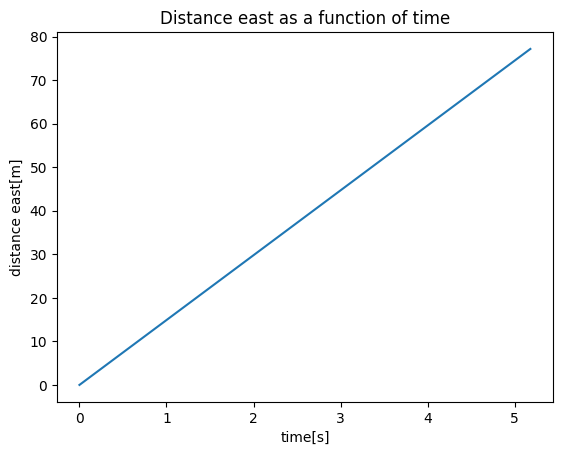

In [32]:
import matplotlib.pyplot as plt
plt.plot(t,x[:,0])  # the "0th"  component of each line in x-- look back at the printout of x
plt.title('Distance east as a function of time')
plt.xlabel('time[s]')
plt.ylabel('distance east[m]')
plt.show()

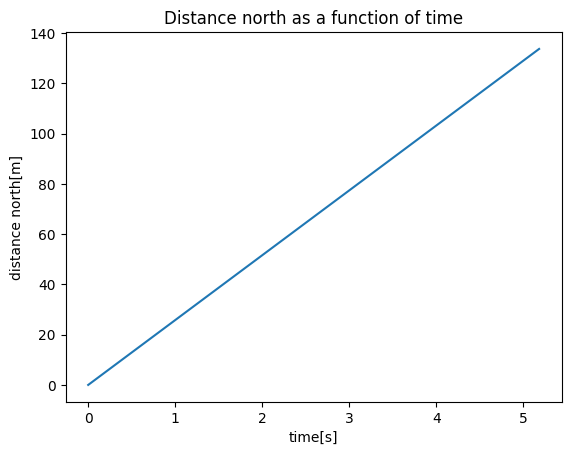

In [33]:
plt.plot(t,x[:,1])
plt.title('Distance north as a function of time')
plt.xlabel('time[s]')
plt.ylabel('distance north[m]')
plt.show()

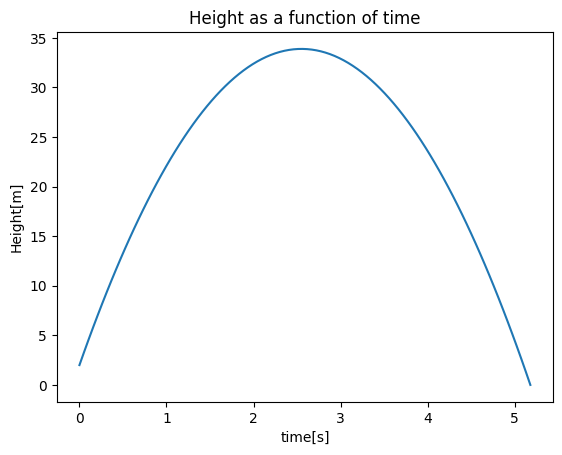

In [34]:
plt.plot(t,x[:,2])
plt.title('Height as a function of time')
plt.xlabel('time[s]')
plt.ylabel('Height[m]')
plt.show()

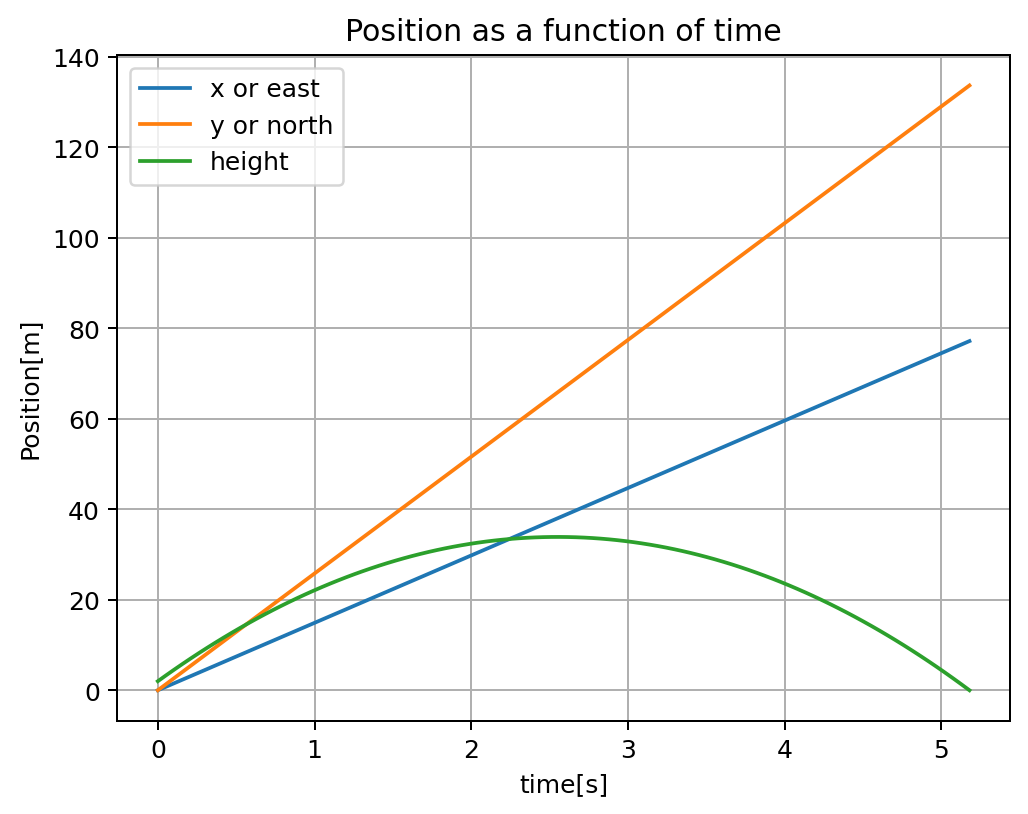

In [35]:
plt.rcParams['figure.dpi'] = 180  #change size of figure
plt.plot(t,x[:,0],label='x or east')
plt.plot(t,x[:,1],label='y or north')
plt.plot(t,x[:,2],label='height')
plt.title('Position as a function of time')
plt.legend()
plt.xlabel('time[s]')
plt.ylabel('Position[m]')
plt.grid()
plt.show()

Now make a plot with 9 subplots to show each component of each vector.

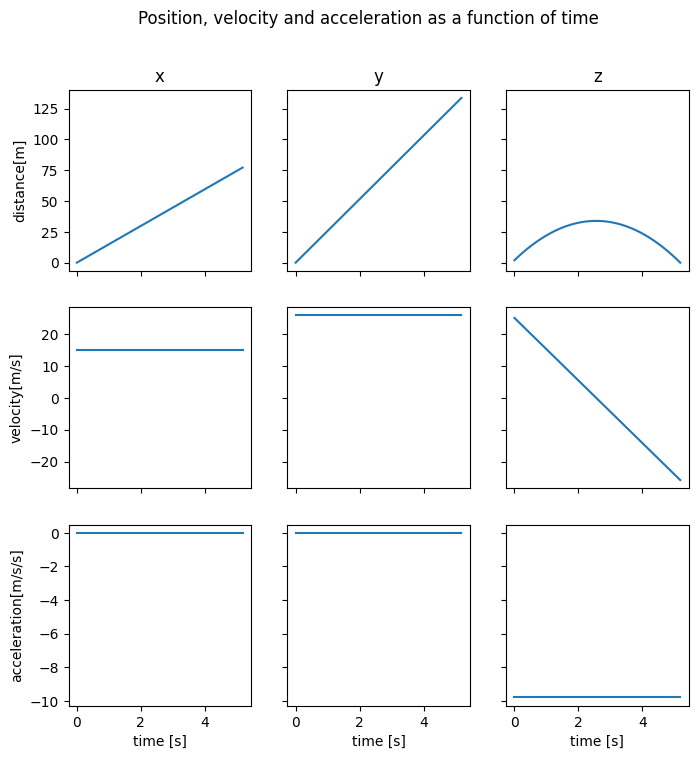

In [51]:
plt.rcParams['figure.figsize']=(8,8) #figure 8" x 8"
plt.rcParams['figure.dpi']=100
fig,ax=plt.subplots(3,3,sharex='col',sharey='row')
fig.suptitle('Position, velocity and acceleration as a function of time') #title for all 9 plots
ax[0][0].plot(t,x[:,0])
ax[0][1].plot(t,x[:,1])
ax[0][2].plot(t,x[:,2])
ax[1][0].plot(t,v[:,0])
ax[1][1].plot(t,v[:,1])
ax[1][2].plot(t,v[:,2])
ax[2][0].plot(t,a0[0]*np.ones(100))
ax[2][1].plot(t,a0[1]*np.ones(100))
ax[2][2].plot(t,a0[2]*np.ones(100))
ax[0][0].set_ylabel('distance[m]')
ax[1][0].set_ylabel('velocity[m/s]')
ax[2][0].set_ylabel('acceleration[m/s/s]')
ax[2][0].set_xlabel('time [s]')
ax[2][1].set_xlabel('time [s]')
ax[2][2].set_xlabel('time [s]')
ax[0][0].set_title('x')
ax[0][1].set_title('y')
ax[0][2].set_title('z')
plt.show()


In [37]:
help(np.linspace)

Help on _ArrayFunctionDispatcher in module numpy:

linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0, *, device=None)
    Return evenly spaced numbers over a specified interval.
    
    Returns `num` evenly spaced samples, calculated over the
    interval [`start`, `stop`].
    
    The endpoint of the interval can optionally be excluded.
    
    .. versionchanged:: 1.16.0
        Non-scalar `start` and `stop` are now supported.
    
    .. versionchanged:: 1.20.0
        Values are rounded towards ``-inf`` instead of ``0`` when an
        integer ``dtype`` is specified. The old behavior can
        still be obtained with ``np.linspace(start, stop, num).astype(int)``
    
    Parameters
    ----------
    start : array_like
        The starting value of the sequence.
    stop : array_like
        The end value of the sequence, unless `endpoint` is set to False.
        In that case, the sequence consists of all but the last of ``num + 1``
        evenly s

## Numerics versus analytical calculations

At this point, all we have done with python is what we would have done with a calculator--- there are no complicated algorithms, but just straight forward calculations.  A few thousand, that would have been tedious to do with a calculator, but no sophistication.  The one place we dabbled was with "Polynomial.roots"-- which can actually find roots for higher order polynomials, and will do things that are very complicated to do analytically.  

## Arrays, Loops and Functions

Python wants you to operate on arrays instead of making loops.  

Lets print out the numbers from 1 to 100, the squares and square roots.

In [52]:
#using a loop
for i in range (1,100):
    print(i,i*i,math.sqrt(i))

1 1 1.0
2 4 1.4142135623730951
3 9 1.7320508075688772
4 16 2.0
5 25 2.23606797749979
6 36 2.449489742783178
7 49 2.6457513110645907
8 64 2.8284271247461903
9 81 3.0
10 100 3.1622776601683795
11 121 3.3166247903554
12 144 3.4641016151377544
13 169 3.605551275463989
14 196 3.7416573867739413
15 225 3.872983346207417
16 256 4.0
17 289 4.123105625617661
18 324 4.242640687119285
19 361 4.358898943540674
20 400 4.47213595499958
21 441 4.58257569495584
22 484 4.69041575982343
23 529 4.795831523312719
24 576 4.898979485566356
25 625 5.0
26 676 5.0990195135927845
27 729 5.196152422706632
28 784 5.291502622129181
29 841 5.385164807134504
30 900 5.477225575051661
31 961 5.5677643628300215
32 1024 5.656854249492381
33 1089 5.744562646538029
34 1156 5.830951894845301
35 1225 5.916079783099616
36 1296 6.0
37 1369 6.082762530298219
38 1444 6.164414002968976
39 1521 6.244997998398398
40 1600 6.324555320336759
41 1681 6.4031242374328485
42 1764 6.48074069840786
43 1849 6.557438524302
44 1936 6.63324958

In [53]:
# using arrays
import numpy as np
i=np.linspace(1,100,100)
print(i,i*i,np.sqrt(i))

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.] [1.000e+00 4.000e+00 9.000e+00 1.600e+01 2.500e+01 3.600e+01 4.900e+01
 6.400e+01 8.100e+01 1.000e+02 1.210e+02 1.440e+02 1.690e+02 1.960e+02
 2.250e+02 2.560e+02 2.890e+02 3.240e+02 3.610e+02 4.000e+02 4.410e+02
 4.840e+02 5.290e+02 5.760e+02 6.250e+02 6.760e+02 7.290e+02 7.840e+02
 8.410e+02 9.000e+02 9.610e+02 1.024e+03 1.089e+03 1.156e+03 1.225e+03
 1.296e+03 1.369e+03 1.444e+03 1.521e+03 1.600e+03 1.681e+03 1.764e+03
 1.849e+03 1.936e+03 2.025e+03 2.116e+03 2.209e+03 2.304e+03 2.40

In [54]:
# or, to put it in the same order
np.set_printoptions(precision=3, suppress='True') #3 decimal places, no scientific notation
print(np.array([i,i*i,np.sqrt(i)]).transpose())

[[    1.        1.        1.   ]
 [    2.        4.        1.414]
 [    3.        9.        1.732]
 [    4.       16.        2.   ]
 [    5.       25.        2.236]
 [    6.       36.        2.449]
 [    7.       49.        2.646]
 [    8.       64.        2.828]
 [    9.       81.        3.   ]
 [   10.      100.        3.162]
 [   11.      121.        3.317]
 [   12.      144.        3.464]
 [   13.      169.        3.606]
 [   14.      196.        3.742]
 [   15.      225.        3.873]
 [   16.      256.        4.   ]
 [   17.      289.        4.123]
 [   18.      324.        4.243]
 [   19.      361.        4.359]
 [   20.      400.        4.472]
 [   21.      441.        4.583]
 [   22.      484.        4.69 ]
 [   23.      529.        4.796]
 [   24.      576.        4.899]
 [   25.      625.        5.   ]
 [   26.      676.        5.099]
 [   27.      729.        5.196]
 [   28.      784.        5.292]
 [   29.      841.        5.385]
 [   30.      900.        5.477]
 [   31.  

In [55]:
#or if we want control over formatting and to get rid of the square brackets
a=np.array([i,i*i,np.sqrt(i)]).transpose()
for k in a:
    print(f'{k[0]:3.0f},{k[1]:5.0f},{k[2]:6.3f}')



  1,    1, 1.000
  2,    4, 1.414
  3,    9, 1.732
  4,   16, 2.000
  5,   25, 2.236
  6,   36, 2.449
  7,   49, 2.646
  8,   64, 2.828
  9,   81, 3.000
 10,  100, 3.162
 11,  121, 3.317
 12,  144, 3.464
 13,  169, 3.606
 14,  196, 3.742
 15,  225, 3.873
 16,  256, 4.000
 17,  289, 4.123
 18,  324, 4.243
 19,  361, 4.359
 20,  400, 4.472
 21,  441, 4.583
 22,  484, 4.690
 23,  529, 4.796
 24,  576, 4.899
 25,  625, 5.000
 26,  676, 5.099
 27,  729, 5.196
 28,  784, 5.292
 29,  841, 5.385
 30,  900, 5.477
 31,  961, 5.568
 32, 1024, 5.657
 33, 1089, 5.745
 34, 1156, 5.831
 35, 1225, 5.916
 36, 1296, 6.000
 37, 1369, 6.083
 38, 1444, 6.164
 39, 1521, 6.245
 40, 1600, 6.325
 41, 1681, 6.403
 42, 1764, 6.481
 43, 1849, 6.557
 44, 1936, 6.633
 45, 2025, 6.708
 46, 2116, 6.782
 47, 2209, 6.856
 48, 2304, 6.928
 49, 2401, 7.000
 50, 2500, 7.071
 51, 2601, 7.141
 52, 2704, 7.211
 53, 2809, 7.280
 54, 2916, 7.348
 55, 3025, 7.416
 56, 3136, 7.483
 57, 3249, 7.550
 58, 3364, 7.616
 59, 3481, 7.6

Now let's use arrays to do the sieve of Erastosthenes to find the prime numbers smaller than N=1000000. We set up an array from 1 to  and Nthen cross out the even numbers, multiples of 3, etc.

In [59]:
N=1000000
N2=int(math.sqrt(N)+1)
#print(N2)
primes=np.linspace(0,N,N+1,dtype='int') # all the integers from 0 to N
primes[1]=0 #1 is not a prime number
print('First hundred elements in starting array ',primes[:100])
printstep=True
for j in primes[:N2]: #only need to go to N2 because any factorization of N needs to have one number less than N2
    if j!=0:
        primes[j*2::j]=0 #cross out every jth number, starting at 2j
        if printstep and j<10:
            print(f'Step {j} Primes are:',primes[:100])
print('Final primes less than 100:',primes[:100].nonzero())
primes=primes.nonzero()[0]#nonzero returns a 2d array,but there is only one row. nonzero returns the index, but the index is the same as the value
print(f'There are {len(primes)} primes less than {N}.  The first 100 are',primes[:100])

First hundred elements in starting array  [ 0  0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Step 2 Primes are: [ 0  0  2  3  0  5  0  7  0  9  0 11  0 13  0 15  0 17  0 19  0 21  0 23
  0 25  0 27  0 29  0 31  0 33  0 35  0 37  0 39  0 41  0 43  0 45  0 47
  0 49  0 51  0 53  0 55  0 57  0 59  0 61  0 63  0 65  0 67  0 69  0 71
  0 73  0 75  0 77  0 79  0 81  0 83  0 85  0 87  0 89  0 91  0 93  0 95
  0 97  0 99]
Step 3 Primes are: [ 0  0  2  3  0  5  0  7  0  0  0 11  0 13  0  0  0 17  0 19  0  0  0 23
  0 25  0  0  0 29  0 31  0  0  0 35  0 37  0  0  0 41  0 43  0  0  0 47
  0 49  0  0  0 53  0 55  0  0  0 59  0 61  0  0  0 65  0 67  0  0  0 71
  0 73  0  0  0 77  0 79  0  0  0 83  0 85  0  0  0 89  0 91  0  0  0 95
  0 97  0  0]
St

## Functions

In python, a function is like any other variable. It is easy to make functions that are arguments of other functions.  A function can even call itself. Let's make a function that finds the lowest factor of a number, and returns the factorization.

In [60]:
def factorize(n):  #return the factorization. Assumes "primes" is long enough....
    for f in primes:
        if n%f==0: # n mod f
            nx=n//f  # integer divide (nx is then also an integer)
            if nx>1:
                return (int(f),factorize(n//f))  #call factorize if there are more factors
            else:
                return int(n)

print(factorize(96))

(2, (2, (2, (2, (2, 3)))))


In [61]:
# We can get rid of the stack of tuples by using a global variable:

In [63]:
def factorize(n):
    global factors
    factors=[]
    nextFactor(n)

def nextFactor(n):  #return the factorization. Assumes "primes" is long enough....
    global factors
    print(n,factors)
    for f in primes:
        if n%f==0:
            nx=n//f
            if nx>1:
                factors.append(int(f))
                nextFactor(n//f)  # a function can call itself!
                return
            else:
                factors.append(int(n))
                return

factorize(480)
print(factors)

480 []
240 [2]
120 [2, 2]
60 [2, 2, 2]
30 [2, 2, 2, 2]
15 [2, 2, 2, 2, 2]
5 [2, 2, 2, 2, 2, 3]
[2, 2, 2, 2, 2, 3, 5]


## Travelling wave
A wave is described by a function $f(x)$ that shows the shape of the function. The make it travel to the right, we transform $x\rightarrow x-vt$, where $v$ is the velocity of the wave.  

Define a function "wave" that transforms any shape function f into a travelling wave. Test it by plotting the sin function s:

$$s(x)=\begin{cases}0 &{x<0,x>\pi} \\ \sin x &{0 \le x \le \pi} \end{cases} $$ 

and the triangle wave 
$$t(x)=\begin{cases} 0 &x<0,x>2 \\ x & 0 \le x < 1 \\ 2-x & 1\le x \le 2 \end{cases}$$

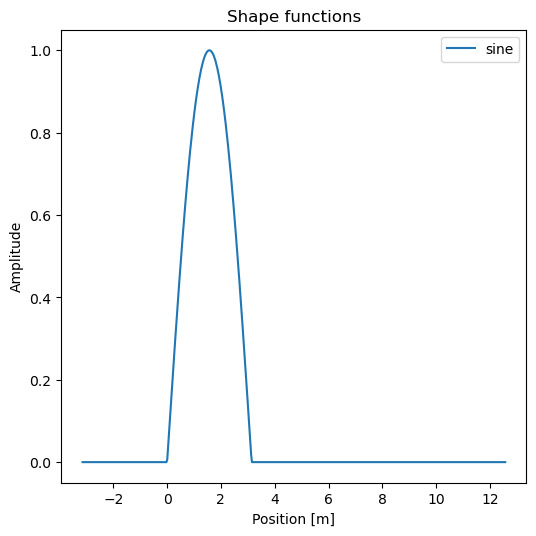

In [118]:
def wave(f,x,t,v): #travelling wave with shape function f, position x, and parameters t, v
    return(f(x-v*t))

def s(x):  #usually, in python, the argument is an array unless you force it
    y=np.sin(x)
#    plt.plot(x,y)
    y[np.asarray(x>math.pi).nonzero()]=0
#    plt.plot(x,y)
    y[np.asarray(x<0).nonzero()]=0
    return y

def tr(x):  #usually, in python, the argument is an array unless you force it
    y=np.zeros_like(x)
#    plt.plot(x,y)
    r=(np.asarray(x>0) *np.asarray(x<=1)).nonzero() #  make a variable r because we use it twice in the next line.
    y[r]=x[r]
#    plt.plot(x,y)
    r=(np.asarray(x>1) *np.asarray(x<=2)).nonzero()
    y[r]=2-x[r]
    return y


#plot the shape functions
plt.rcParams['figure.figsize']=(6,6) #figure 6" x 6"
plt.rcParams['figure.dpi']=100
xr=np.linspace(-1*math.pi,4*math.pi,500)
plt.plot(xr,s(xr),label='sine')
#plt.plot(xr,tr(xr),label='triangle')
plt.title("Shape functions")
plt.ylabel("Amplitude")
plt.xlabel("Position [m]")
plt.legend()
plt.show()

v=2 #m/s wave velocity



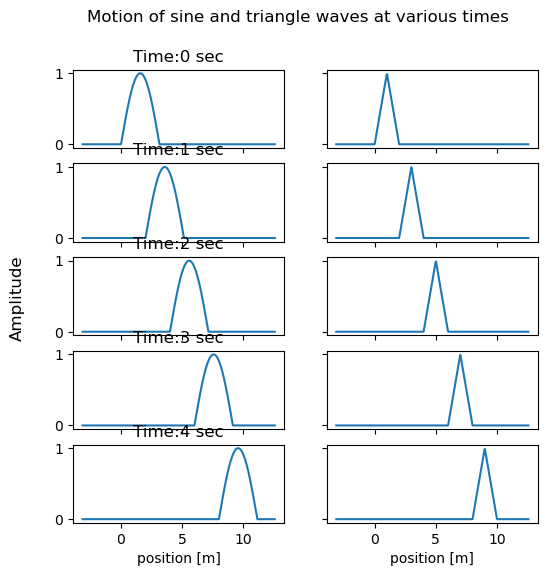

In [120]:
fig,ax=plt.subplots(5,2,sharex=True, sharey=True)
fig.suptitle('Motion of sine and triangle waves at various times')
fig.supylabel('Amplitude')
ax[4][0].set_xlabel('position [m]')
ax[4][1].set_xlabel('position [m]')
for t in (0,1,2,3,4):
    ax[t][0].plot(xr,wave(s,xr,v,t))
    ax[t][1].plot(xr,wave(tr,xr,v,t))
    ax[t][0].set_title(f'Time:{t} sec')

np.zeros_like(xr)